In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import os
import glob
import sys
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn import preprocessing

In [2]:
import random
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [3]:
data_path = r"path\Train_Test_Verification_Data.xlsx"

train_data = pd.read_excel(data_path, sheet_name="Train")
test_data = pd.read_excel(data_path, sheet_name="Test")


feature_train = train_data.iloc[:, :10].to_numpy(dtype=np.float32)
label_train = train_data.iloc[:, -1].to_numpy(dtype=np.float32)

feature_test = test_data.iloc[:, :10].to_numpy(dtype=np.float32)
label_test = test_data.iloc[:, -1].to_numpy(dtype=np.float32)

print("Train:", feature_train.shape, label_train.shape)
print("Test :", feature_test.shape, label_test.shape)

Train: (71520, 10) (71520,)
Test : (30652, 10) (30652,)


## Model training of DNN

In [4]:
class ExcelDataset(Dataset):
    def __init__(self):
        self.feature = feature_train  
        self.label=label_train  
        self.x = torch.from_numpy(self.feature).float()
        self.y = torch.from_numpy(self.label).float()
    def __len__(self):
        return len(self.y)
    def __getitem__(self, index):
        x=self.x[index]
        y=self.y[index]
        return {'x':x,'y':y}

dataset=ExcelDataset()
dataloader=DataLoader(dataset=dataset, batch_size=256,shuffle=True,num_workers=0,drop_last = True)

In [5]:
import torch.nn.init as init
class BP(nn.Module):
    def __init__(self, num_layers,hidden_size):
        super(BP,self).__init__()
        self.Liner1 = nn.Linear(10,hidden_size)
        self.queue= [nn.Sequential(nn.Linear(hidden_size, hidden_size), nn.LeakyReLU(0.1)) for _ in range(num_layers - 1)]
        self.model=nn.Sequential(*self.queue)
        self.Liner2 = nn.Linear(hidden_size,1)
        
        
    def forward(self,input):
        output = self.Liner1(input)
        output=self.model(output)
        output = self.Liner2(output)
        return output
n_epochs =50
bp=BP(4,48)
optimizer = torch.optim.Adam(bp.parameters(), lr=0.01)
MSEloss=nn.MSELoss()

In [8]:
def train():
    loss_mean_best = 10000
    loss_train = np.zeros(n_epochs)
    loss_val = np.zeros(n_epochs)
    epoch_best = 1

    patience = 5
    min_delta = 1e-1
    wait = 0
    best_model = None

    for epoch in range(0, n_epochs):
        bp.train()
        accuracy_mean = 0
        loss_mean = 0

        for i, value in enumerate(dataloader):
            x = value['x']
            y = value['y']

            y_train = bp(x)
            y_train = y_train.squeeze(1)

            loss = MSEloss(y, y_train)
            loss_mean += loss.item()
            accuracy = r2_score(y.detach().numpy(), y_train.detach().numpy())
            accuracy_mean += accuracy

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        loss_train_epoch_running = loss_mean / len(dataloader)

        bp.eval()
        train_loss_eval = 0

        with torch.no_grad():
            for value in dataloader:
                x = value['x']
                y = value['y']

                y_train = bp(x)
                y_train = y_train.squeeze(1)

                loss = MSEloss(y, y_train)
                train_loss_eval += loss.item()

            train_loss_eval = train_loss_eval / len(dataloader)
            loss_train[epoch] = train_loss_eval
            _, loss_val1 = test(feature_test, label_test)
            loss_val[epoch] = loss_val1

        print(
            "\r[Epoch %d/%d] [Batch %d/%d] [loss_train_running: %f] [loss_train_eval: %f] [loss_val: %f]"
            % (
                epoch + 1,
                n_epochs,
                i + 1,
                len(dataloader),
                loss_train_epoch_running,
                train_loss_eval,
                loss_val1,
            )
        )

        if epoch > 10:
            if loss_val[epoch] < loss_mean_best - min_delta:
                loss_mean_best = loss_val[epoch]
                epoch_best = epoch + 1
                wait = 0
                best_model = copy.deepcopy(bp.state_dict())
            else:
                wait += 1

            if wait >= patience:
                print(
                    "Early stopping at epoch %d, best epoch = %d, best val loss = %f"
                    % (epoch + 1, epoch_best, loss_mean_best)
                )
                break

    if best_model is not None:
        bp.load_state_dict(best_model)

    return epoch_best, loss_train[:epoch + 1], loss_val[:epoch + 1]

In [9]:
def test(feature_test, label_test):
    predict_list=[]
    bp.eval()
    for test_feature in feature_test:
        test_feature = torch.from_numpy(test_feature).float()
        test_feature=test_feature.unsqueeze(0)
        predict=bp(test_feature)
        predict=predict.squeeze(1)
        predict=predict.squeeze(0)
        predict_list.append(predict.detach().numpy())
 
    predict_list=np.array(predict_list)
    loss = MSEloss(torch.from_numpy(predict_list),torch.from_numpy(label_test)).item()
    print("[R2:{}][loss:{}]".format(r2_score(label_test,predict_list), loss))
    return predict_list, loss

In [10]:
epoch_best,loss_train, loss_test = train() ## re-train the model

[R2:0.9329719481811682][loss:78.5849380493164]
[Epoch 1/50] [Batch 279/279] [loss_train_running: 544.599492] [loss_train_eval: 93.671595] [loss_val: 78.584938]


KeyboardInterrupt: 

In [11]:
##Load the parameters of the trained model consistent with the work
model_path = r"path\DNN_BP_4_48_final.pth"
bp.load_state_dict(torch.load(model_path))
bp.eval()
predict_list, loss_val= test(feature_test,label_test)

[R2:0.9948051228526013][loss:6.090571880340576]


## DNN Model verification

In [4]:
class ExcelDataset(Dataset):
    def __init__(self):
        self.feature = feature_train  
        self.label=label_train  
        self.x = torch.from_numpy(self.feature).float()
        self.y = torch.from_numpy(self.label).float()
    def __len__(self):
        return len(self.y)
    def __getitem__(self, index):
        x=self.x[index]
        y=self.y[index]
        return {'x':x,'y':y}

dataset=ExcelDataset()
dataloader=DataLoader(dataset=dataset, batch_size=256,shuffle=True,num_workers=0,drop_last = True)

In [5]:
import torch.nn.init as init
class BP(nn.Module):
    def __init__(self, num_layers,hidden_size):
        super(BP,self).__init__()
        self.Liner1 = nn.Linear(10,hidden_size)
        self.queue= [nn.Sequential(nn.Linear(hidden_size, hidden_size), nn.LeakyReLU(0.1)) for _ in range(num_layers - 1)]
        self.model=nn.Sequential(*self.queue)
        self.Liner2 = nn.Linear(hidden_size,1)
        
        
    def forward(self,input):
        output = self.Liner1(input)
        output=self.model(output)
        output = self.Liner2(output)

        return output
n_epochs =50
bp=BP(4,48)
optimizer = torch.optim.Adam(bp.parameters(), lr=0.01)
MSEloss=nn.MSELoss()

In [6]:
def train():
    loss_mean_best = 10000
    loss_train = np.zeros(n_epochs)
    loss_val = np.zeros(n_epochs)
    epoch_best = 1

    patience = 5
    min_delta = 1e-1
    wait = 0
    best_model = None

    for epoch in range(0, n_epochs):
        bp.train()
        accuracy_mean = 0
        loss_mean = 0

        for i, value in enumerate(dataloader):
            x = value['x']
            y = value['y']

            y_train = bp(x)
            y_train = y_train.squeeze(1)

            loss = MSEloss(y, y_train)
            loss_mean += loss.item()
            accuracy = r2_score(y.detach().numpy(), y_train.detach().numpy())
            accuracy_mean += accuracy

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        loss_train_epoch_running = loss_mean / len(dataloader)

        bp.eval()
        train_loss_eval = 0

        with torch.no_grad():
            for value in dataloader:
                x = value['x']
                y = value['y']

                y_train = bp(x)
                y_train = y_train.squeeze(1)

                loss = MSEloss(y, y_train)
                train_loss_eval += loss.item()

            train_loss_eval = train_loss_eval / len(dataloader)

            loss_train[epoch] = train_loss_eval

            _, loss_val1 = test(feature_test, label_test)
            loss_val[epoch] = loss_val1

        print(
            "\r[Epoch %d/%d] [Batch %d/%d] [loss_train_running: %f] [loss_train_eval: %f] [loss_val: %f]"
            % (
                epoch + 1,
                n_epochs,
                i + 1,
                len(dataloader),
                loss_train_epoch_running,
                train_loss_eval,
                loss_val1,
            )
        )

        if epoch > 10:
            if loss_val[epoch] < loss_mean_best - min_delta:
                loss_mean_best = loss_val[epoch]
                epoch_best = epoch + 1
                wait = 0
                best_model = copy.deepcopy(bp.state_dict())
            else:
                wait += 1

            if wait >= patience:
                print(
                    "Early stopping at epoch %d, best epoch = %d, best val loss = %f"
                    % (epoch + 1, epoch_best, loss_mean_best)
                )
                break

    if best_model is not None:
        bp.load_state_dict(best_model)

    return epoch_best, loss_train[:epoch + 1], loss_val[:epoch + 1]

In [7]:
def test(feature_test, label_test):
    predict_list=[]
    bp.eval()
    for test_feature in feature_test:
        test_feature = torch.from_numpy(test_feature).float()
        test_feature=test_feature.unsqueeze(0)

        predict=bp(test_feature)
        predict=predict.squeeze(1)
        predict=predict.squeeze(0)
        predict_list.append(predict.detach().numpy())
 
    predict_list=np.array(predict_list)
    loss = MSEloss(torch.from_numpy(predict_list),torch.from_numpy(label_test)).item()
    print("[R2:{}][loss:{}]".format(r2_score(label_test,predict_list), loss))
    return predict_list, loss

In [8]:
##Load the parameters of the trained model consistent with the work
model_path = r"path\DNN_BP_4_48_final.pth"
bp.load_state_dict(torch.load(model_path))
bp.eval()
predict_list, loss_val= test(feature_test,label_test)

[R2:0.9948051228526013][loss:6.090571880340576]


In [9]:
## verification inputs
data_path_val = r"path/Train_Test_Verification_Data.xlsx"
val_feature = pd.read_excel(data_path_val,sheet_name='Verification-inputs').iloc[:,:10]

## verification experiments
file_path = r"path/Train_Test_Verification_Data.xlsx"
true_df = pd.read_excel(
    file_path,
    sheet_name="Verification experiments"
)

In [10]:
## verification experiments
file_path = r"path/Train_Test_Verification_Data.xlsx"
true_df = pd.read_excel(
    file_path,
    sheet_name="Verification experiments"
)

In [11]:
## Function definition
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import r2_score, mean_squared_error


def predict_dnn(bp, feature_eval):
    bp.eval()

    if isinstance(feature_eval, pd.DataFrame):
        feature_eval = feature_eval.to_numpy(dtype=np.float32)
    else:
        feature_eval = np.asarray(feature_eval, dtype=np.float32)

    predict_list = []

    with torch.no_grad():
        for test_feature in feature_eval:
            test_feature = torch.from_numpy(test_feature).float()
            test_feature = test_feature.unsqueeze(0)

            predict = bp(test_feature)
            predict = predict.squeeze(1)
            predict = predict.squeeze(0)

            predict_list.append(predict.detach().cpu().numpy())

    predict_list = np.array(predict_list).reshape(-1)

    return predict_list


print("val_feature type:", type(val_feature))

if isinstance(val_feature, pd.DataFrame):
    print("val_feature shape:", val_feature.shape)
else:
    print("val_feature shape:", np.asarray(val_feature).shape)

dnn_pre = predict_dnn(bp, val_feature)

group_size = 574
n_groups = 15


pred_df = pd.DataFrame({
    f"Exp_{i+1}": dnn_pre[i * group_size:(i + 1) * group_size]
    for i in range(n_groups)
})

pred_df_eval = pred_df.copy()
pred_df_eval.columns = true_df.columns


from scipy.signal import savgol_filter## For proper presentation and comparision
window_length_set=131
polyorder_set=1
def smooth_prediction_curves(df, window_length=window_length_set, polyorder=polyorder_set):
    df_smooth = df.copy().astype(float)

    for col in df_smooth.columns:
        y = df_smooth[col].to_numpy(dtype=float)

        w = window_length
        if w >= len(y):
            w = len(y) - 1
        if w % 2 == 0:
            w -= 1
        if w <= polyorder:
            w = polyorder + 3
            if w % 2 == 0:
                w += 1

        y_smooth = savgol_filter(
            y,
            window_length=w,
            polyorder=polyorder,
            mode="nearest"
        )

        df_smooth[col] = y_smooth

    return df_smooth


pred_df_smooth = smooth_prediction_curves(
    pred_df_eval,
    window_length=window_length_set,
    polyorder=polyorder_set
)



def normalize_first_point_to_100(df):## For proper presentation and comparision
    df_corrected = df.copy().astype(float)

    for col in df_corrected.columns:
        first_value = df_corrected[col].iloc[0]
        correction = 100 - first_value
        df_corrected[col] = df_corrected[col] + correction

    return df_corrected


true_df_corrected = normalize_first_point_to_100(true_df)
pred_df_corrected = normalize_first_point_to_100(pred_df_smooth)

val_feature type: <class 'pandas.core.frame.DataFrame'>
val_feature shape: (8610, 10)


In [12]:
#Show the analysis results
results = []

epsilon = 1e-8

for col in true_df_corrected.columns:
    y_true = true_df_corrected[col].to_numpy(dtype=float)
    y_pred = pred_df_corrected[col].to_numpy(dtype=float)

    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    mask = mask & np.isfinite(y_true) & np.isfinite(y_pred)

    y_true_valid = y_true[mask]
    y_pred_valid = y_pred[mask]

    error = y_pred_valid - y_true_valid
    abs_error = np.abs(error)

    r2 = r2_score(y_true_valid, y_pred_valid)
    rmse = np.sqrt(mean_squared_error(y_true_valid, y_pred_valid))
    mae = np.mean(abs_error)
    mbe = np.mean(error)

    # MedAE
    medae = np.median(abs_error)

    # sMAPE
    smape = 200 * np.mean(
        np.abs(y_pred_valid - y_true_valid) /
        np.maximum(
            np.abs(y_true_valid) + np.abs(y_pred_valid),
            epsilon
        )
    )


    results.append({
        "Experiment": col,
        "N_points": len(y_true_valid),

        "R2": r2,
        "RMSE": rmse,
        "MAE": mae,
        "MBE": mbe,
        "MedAE": medae,
        "sMAPE(%)": smape,
    })

results_df = pd.DataFrame(results)


metric_cols = [
    "R2",
    "RMSE",
    "MAE",
    "MBE",
    "MedAE",
    "sMAPE(%)",
]

summary_df = results_df[metric_cols].agg(
    ["mean", "std", "min", "max", "median"]
).T.reset_index()

summary_df = summary_df.rename(columns={
    "index": "Metric",
    "mean": "Mean",
    "std": "Std",
    "min": "Min",
    "max": "Max",
    "median": "Median"
})
print("\nDNN evaluation results for each experiment:")
display(results_df)

print("\nSummary of verfication results:")
display(summary_df)


DNN evaluation results for each experiment:


,Experiment,N_points,R2,RMSE,MAE,MBE,MedAE,sMAPE(%)
0,Exp1,574,0.991159,2.448445,2.054395,1.412767,1.746720,4.674736
1,Exp2,574,0.990525,2.986994,2.593390,-2.117531,2.754691,11.672596
2,Exp3,574,0.990479,2.735435,2.292681,1.647182,1.890065,4.773081
3,Exp4,574,0.992173,2.366786,2.086714,-2.078223,2.338429,4.649706
4,Exp5,574,0.992522,2.753977,2.313432,-1.081135,2.040951,6.260969
5,Exp6,574,0.993572,2.106340,1.913496,-1.906494,2.178025,4.949881
6,Exp7,574,0.992568,2.246599,1.883554,-1.864807,1.664376,4.717909
7,Exp8,574,0.990240,2.594844,2.260540,-2.192862,2.249846,6.061133
8,Exp9,574,0.990434,2.999603,2.514587,-2.396135,2.459090,9.093601
9,Exp10,574,0.992078,2.323301,1.984330,-1.959022,1.944132,4.999483



Summary of verfication results:


,Metric,Mean,Std,Min,Max,Median
0,R2,0.991485,0.000988,0.990240,0.993572,0.991141
1,RMSE,2.613319,0.286560,2.106340,2.999603,2.594844
2,MAE,2.221618,0.240935,1.883554,2.643079,2.257222
3,MBE,-0.421240,1.989350,-2.396135,2.643079,-1.864807
4,MedAE,2.047039,0.369595,1.433353,2.754691,1.944132
5,sMAPE(%),6.121388,2.084866,4.274357,11.672596,4.999483


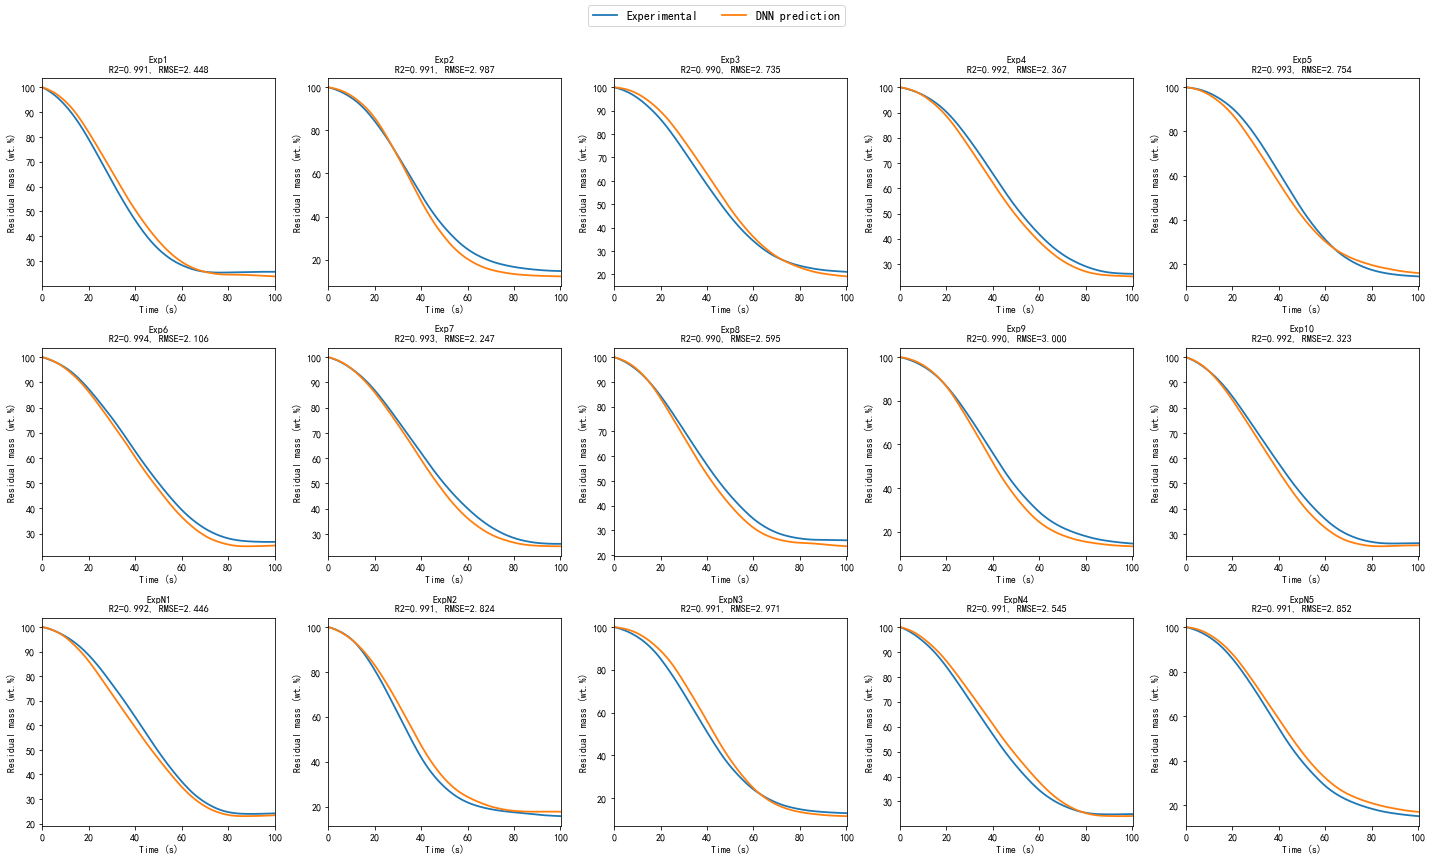

In [13]:
##Show the figure results
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
for col in true_df_corrected.columns:
    y_true = true_df_corrected[col].to_numpy(dtype=float)
    y_pred = pred_df_corrected[col].to_numpy(dtype=float)

    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    mask = mask & np.isfinite(y_true) & np.isfinite(y_pred)

    y_true_valid = y_true[mask]
    y_pred_valid = y_pred[mask]

    error = y_pred_valid - y_true_valid
    abs_error = np.abs(error)

    r2 = r2_score(y_true_valid, y_pred_valid)
    rmse = np.sqrt(mean_squared_error(y_true_valid, y_pred_valid))
    mae = np.mean(abs_error)
    mbe = np.mean(error)

    # MedAE
    medae = np.median(abs_error)

    # sMAPE
    smape = 200 * np.mean(
        np.abs(y_pred_valid - y_true_valid) /
        np.maximum(
            np.abs(y_true_valid) + np.abs(y_pred_valid),
            epsilon
        )
    )


    results.append({
        "Experiment": col,
        "N_points": len(y_true_valid),

        "R2": r2,
        "RMSE": rmse,
        "MAE": mae,
        "MBE": mbe,
        "MedAE": medae,
        "sMAPE(%)": smape,
    })

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

n_points = true_df_corrected.shape[0]
time_axis = np.arange(n_points) * 0.175


cols = true_df_corrected.columns.tolist()
n_plots = len(cols)

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]

    y_true = true_df_corrected[col].to_numpy(dtype=float)
    y_pred = pred_df_corrected[col].to_numpy(dtype=float)

    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    y_true_valid = y_true[mask]
    y_pred_valid = y_pred[mask]

    r2 = r2_score(y_true_valid, y_pred_valid)
    rmse = np.sqrt(mean_squared_error(y_true_valid, y_pred_valid))

    ax.plot(time_axis, y_true, label="Experimental", linewidth=1.8)
    ax.plot(time_axis, y_pred, label="DNN prediction", linewidth=1.8)

    ax.set_title(f"{col}\nR2={r2:.3f}, RMSE={rmse:.3f}", fontsize=10)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Residual mass (wt.%)")

    ax.set_xlim(time_axis[0], time_axis[-1])

for j in range(n_plots, len(axes)):
    axes[j].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    fontsize=12
)

plt.tight_layout(rect=[0, 0, 1, 0.95])